Exercício
1) Escolha um dado do Kaggle - ** resting blood pressure**

2) Defina um problema -** problema de aprendizagem supervizionado**
3) Escolha a classe de modelos - **regressão linear**
4) Aplique pelo menos duas técnicas de aprendizado de máquina que foram apresentadas no curso (escrevam no documento quais técnicas foram utilizadas) - **regularização e bootstrap**
5) Conclua respondendo o problema



# Task
Analyze the data in the file "heart.csv" by performing a summary and a linear regression analysis.

## Carregar os dados

### Subtask:
Carregar o arquivo `heart.csv` em um DataFrame pandas.


**Reasoning**:
Import the pandas library, read the CSV file into a DataFrame, and display the first 5 rows.



In [ ]:
df = pd.read_csv('/content/sample_data/heart.csv')
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Resumir os dados

### Subtask:
Exibir um resumo estatístico do DataFrame para entender a distribuição e as características dos dados.


**Reasoning**:
Display a concise summary and descriptive statistics of the DataFrame to understand the data distribution and characteristics.



In [ ]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


## Preparar os dados para regressão

### Subtask:
Selecionar as colunas relevantes para a análise de regressão linear e verificar se há valores ausentes ou inconsistentes.


**Reasoning**:
Select relevant columns for linear regression, check for missing values, and identify potential inconsistencies.



In [ ]:
# Identify relevant columns for linear regression. Numerical columns can be used directly,
# and categorical columns (object type) will need one-hot encoding.
relevant_columns = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

# Create a subset DataFrame with only the relevant columns (in this case, all columns are deemed potentially relevant).
df_relevant = df[relevant_columns].copy()

# Check for missing values in the selected columns
missing_values = df_relevant.isnull().sum()
print("Missing values per column:")
print(missing_values)

# Check for inconsistencies in data types (already partially done with .info(), but good to re-confirm)
print("\nData types of selected columns:")
print(df_relevant.dtypes)

# For categorical columns, check unique values to identify potential inconsistencies or values
categorical_cols = df_relevant.select_dtypes(include='object').columns
print("\nUnique values for categorical columns:")
for col in categorical_cols:
    print(f"- {col}: {df_relevant[col].unique()}")

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Data types of selected columns:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Unique values for categorical columns:
- Sex: ['M' 'F']
- ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
- RestingECG: ['Normal' 'ST' 'LVH']
- ExerciseAngina: ['N' 'Y']
- ST_Slope: ['Up' 'Flat' 'Down']


## Realizar a análise de regressão linear

### Subtask:
Aplicar um modelo de regressão linear aos dados.


**Reasoning**:
Identify the dependent and independent variables, separate the data, and apply one-hot encoding to the categorical independent variables.



In [ ]:
# 1. Identifique a variável dependente (target) e as variáveis independentes (features) para a análise de regressão.
# The target variable is HeartDisease, which is the outcome we want to predict.
# All other columns in df_relevant will be used as features.

# 2. Separe os dados em variáveis independentes (X) e variável dependente (y).
y = df_relevant['HeartDisease']
X = df_relevant.drop('HeartDisease', axis=1)

# 3. Lide com as variáveis categóricas nas variáveis independentes X utilizando one-hot encoding.
X = pd.get_dummies(X, drop_first=True)

# 4. Importe e instancie o modelo LinearRegression do módulo sklearn.linear_model.
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# 5. Ajuste o modelo de regressão linear aos dados preparados (X e y).
model.fit(X, y)

print("Linear Regression model fitted successfully.")

Linear Regression model fitted successfully.


## Exibir os resultados da regressão

### Subtask:
Apresentar os coeficientes, R-quadrado e outras métricas relevantes do modelo de regressão.


**Reasoning**:
Print the intercept, coefficients, and R-squared of the fitted linear regression model, and calculate and print the Mean Squared Error (MSE) and Root Mean Squared Error (RMSE).



In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Print the intercept of the linear regression model
print("Intercept:", model.intercept_)

# 2. Print the coefficients of the linear regression model
print("\nCoefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"- {col}: {coef}")

# 3. Calculate and print the R-squared of the model
r_squared = model.score(X, y)
print("\nR-squared:", r_squared)

# 4. Calculate and print other relevant metrics (MSE, RMSE)
y_pred = model.predict(X)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("\nMean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Intercept: 0.47401952715618056

Coefficients:
- Age: 0.0022306181565410733
- RestingBP: 0.00020947379926903806
- Cholesterol: -0.0005118448263364481
- FastingBS: 0.13114868661943554
- MaxHR: -0.0006424437092881993
- Oldpeak: 0.04978007519997173
- Sex_M: 0.15825602026712968
- ChestPainType_ATA: -0.247036610984366
- ChestPainType_NAP: -0.22902509237089771
- ChestPainType_TA: -0.19152900659224673
- RestingECG_Normal: -0.018728662592181387
- RestingECG_ST: -0.019423777642276794
- ExerciseAngina_Y: 0.13576600789102647
- ST_Slope_Flat: 0.16076674719438755
- ST_Slope_Up: -0.21247337160863403

R-squared: 0.5757101767807938

Mean Squared Error (MSE): 0.10486361416085963
Root Mean Squared Error (RMSE): 0.32382651861893524


## Summary:

### Data Analysis Key Findings
*   The dataset contains 918 entries and 12 columns with no missing values.
*   About 57.6% of the variance in the target variable ('HeartDisease') can be explained by the predictor variables in the linear regression model, as indicated by the R-squared value of approximately 0.576.
*   Being male, having fasting blood sugar > 120 mg/dl, experiencing exercise-induced angina, and having a flat ST slope during exercise are positively associated with the target variable.
*   Atypical Angina, Non-Anginal Pain, Typical Angina chest pain types, and an upsloping ST segment during exercise are negatively associated with the target variable.
*   The Mean Squared Error (MSE) is approximately 0.105, and the Root Mean Squared Error (RMSE) is approximately 0.324, indicating the average magnitude of prediction errors.

### Insights or Next Steps
*   The linear regression model provides a moderate explanation of the variance in heart disease prediction.
*   Further analysis could explore feature importance, non-linear relationships, or alternative classification models given the binary nature of the 'HeartDisease' target variable.



Exercício
1) Escolha um dado do Kaggle - vou analisar os dados de pressão arterial em repouso

2) Defina um problema  - problema de Aprendizagem Supervisionada

3) Escolha a classe de modelos  - modelo de regressão lienar
4) Aplique pelo menos duas técnicas de aprendizado de máquina que foram apresentadas no curso (escrevam no documento quais técnicas foram utilizadas) -  vou usar regularização e bootstrap


# Task
Realize uma análise de regressão linear com regularização Lasso na variável 'RestingBP' do dataset "heart.csv", explicando o que cada variável representa e avaliando o modelo.

## Preparar os dados para regressão

### Subtask:
Selecionar as colunas relevantes para a análise de regressão linear, lidar com variáveis categóricas e separar os dados em variáveis independentes (X) e variável dependente (y).


**Reasoning**:
Define the dependent and independent variables, apply one-hot encoding to the categorical features, and separate the data.



In [ ]:
# 1. Definir a variável dependente (y) como a coluna 'RestingBP' do DataFrame df.
y = df['RestingBP']

# 2. Definir as variáveis independentes (X) como todas as outras colunas do DataFrame df, excluindo 'RestingBP'.
X = df.drop('RestingBP', axis=1)

# 3. Aplicar one-hot encoding às variáveis categóricas nas variáveis independentes X, utilizando pd.get_dummies e removendo a primeira categoria de cada variável para evitar multicolinearidade.
X = pd.get_dummies(X, drop_first=True)

print("Dependent variable (y) and independent variables (X) defined.")
print("Categorical variables in X have been one-hot encoded.")
display(X.head())
display(y.head())

Dependent variable (y) and independent variables (X) defined.
Categorical variables in X have been one-hot encoded.


,Age,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


,RestingBP
0,140
1,160
2,130
3,138
4,150


## Dividir os dados

### Subtask:
Dividir os dados em conjuntos de treino e teste para avaliar o desempenho do modelo.


**Reasoning**:
Import train_test_split and split the data into training and testing sets, then display the shapes of the resulting sets.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shapes of the training and testing sets:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Shapes of the training and testing sets:
X_train shape: (734, 15)
X_test shape: (184, 15)
y_train shape: (734,)
y_test shape: (184,)


## Aplicar regularização lasso

### Subtask:
Treinar um modelo de Regressão Lasso nos dados de treino.


**Reasoning**:
Train a Lasso regression model on the training data.



In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X_train, y_train)

print("Lasso model fitted successfully on the training data.")

Lasso model fitted successfully on the training data.


## Avaliar o modelo

### Subtask:
Avaliar o desempenho do modelo nos dados de teste usando métricas relevantes para regressão.


**Reasoning**:
Evaluate the Lasso model performance on the test set using MSE, R-squared, and RMSE.



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Use the trained lasso_model to make predictions on the test set features (X_test)
y_pred = lasso_model.predict(X_test)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) on test set: {mse:.4f}")

# Calculate the R-squared score
r2 = r2_score(y_test, y_pred)
print(f"R-squared score on test set: {r2:.4f}")

# Calculate the Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE) on test set: {rmse:.4f}")

Mean Squared Error (MSE) on test set: 340.3203
R-squared score on test set: 0.0135
Root Mean Squared Error (RMSE) on test set: 18.4478


## Interpretar os resultados

### Subtask:
Apresentar os coeficientes do modelo Lasso e as métricas de avaliação, discutindo o que eles significam.


**Reasoning**:
Print the intercept and coefficients of the Lasso model and then provide an interpretation of the results and metrics.



In [ ]:
# 1. Print the intercept of the Lasso model
print("Lasso Model Intercept:", lasso_model.intercept_)

# 2. Print the coefficients of the Lasso model
print("\nLasso Model Coefficients:")
for col, coef in zip(X.columns, lasso_model.coef_):
    print(f"- {col}: {coef}")

# 3. Interpret the results and metrics
print("\nInterpretation of Lasso Regression Results:")
print(f"The Lasso model attempts to predict 'RestingBP' (Resting Blood Pressure).")
print(f"The Intercept ({lasso_model.intercept_:.4f}) represents the predicted RestingBP when all independent variables are zero.")
print("\nThe coefficients indicate the estimated change in 'RestingBP' for a one-unit increase in the corresponding independent variable, holding other variables constant. Lasso regression can shrink some coefficients to zero, effectively performing feature selection.")

# Interpret the coefficients focusing on non-zero ones
non_zero_coefs = [(col, coef) for col, coef in zip(X.columns, lasso_model.coef_) if coef != 0]
if non_zero_coefs:
    print("\nNon-zero coefficients and their meaning:")
    for col, coef in non_zero_coefs:
        print(f"- {col}: {coef:.4f} - A {coef:.4f} unit increase in {col} is associated with a change of {coef:.4f} in RestingBP.")
else:
    print("\nAll coefficients are zero, indicating that none of the features were selected by the Lasso model with the current alpha.")


print(f"\nEvaluation Metrics:")
print(f"- R-squared ({r2:.4f}): This metric represents the proportion of the variance in 'RestingBP' that is predictable from the independent variables. An R-squared of {r2:.4f} means that only {r2*100:.2f}% of the variance in RestingBP is explained by this model. This is a very low value, suggesting the model does not explain much of the variability in RestingBP.")
print(f"- Mean Squared Error (MSE) ({mse:.4f}): This is the average of the squared errors between the actual and predicted 'RestingBP' values. A lower MSE indicates a better fit. The MSE of {mse:.4f} represents the average squared difference between the actual and predicted RestingBP values.")
print(f"- Root Mean Squared Error (RMSE) ({rmse:.4f}): This is the square root of the MSE and is in the same units as 'RestingBP'. An RMSE of {rmse:.4f} means that, on average, the model's predictions are about {rmse:.4f} units away from the actual RestingBP values.")

print("\nOverall Assessment:")
print(f"Based on the low R-squared ({r2:.4f}) and relatively high MSE ({mse:.4f}) and RMSE ({rmse:.4f}), this Lasso regression model does not appear to be a strong predictor of 'RestingBP' using the selected features and the chosen alpha value.")

Lasso Model Intercept: 107.51571965349046

Lasso Model Coefficients:
- Age: 0.503047890990952
- Cholesterol: 0.01891183650632176
- FastingBS: 0.0
- MaxHR: -0.04219952973609915
- Oldpeak: 0.5850064260537748
- HeartDisease: 0.0
- Sex_M: 0.0
- ChestPainType_ATA: -0.0
- ChestPainType_NAP: -0.0
- ChestPainType_TA: 0.0
- RestingECG_Normal: -0.0
- RestingECG_ST: 0.0
- ExerciseAngina_Y: 0.0
- ST_Slope_Flat: 0.0
- ST_Slope_Up: -0.0

Interpretation of Lasso Regression Results:
The Lasso model attempts to predict 'RestingBP' (Resting Blood Pressure).
The Intercept (107.5157) represents the predicted RestingBP when all independent variables are zero.

The coefficients indicate the estimated change in 'RestingBP' for a one-unit increase in the corresponding independent variable, holding other variables constant. Lasso regression can shrink some coefficients to zero, effectively performing feature selection.

Non-zero coefficients and their meaning:
- Age: 0.5030 - A 0.5030 unit increase in Age is a

## Summary:

### Data Analysis Key Findings

*   The dataset was successfully split into training (734 samples) and testing (184 samples) sets.
*   A Lasso regression model was trained to predict 'RestingBP'.
*   The evaluation metrics for the Lasso model on the test set are:
    *   Mean Squared Error (MSE): 340.3203
    *   R-squared score: 0.0135
    *   Root Mean Squared Error (RMSE): 18.4478
*   The R-squared value of 0.0135 indicates that only about 1.35% of the variance in 'RestingBP' is explained by the model.
*   The RMSE of 18.4478 suggests that, on average, the model's predictions are approximately 18.45 units away from the actual 'RestingBP' values.
*   The Lasso regularization shrank several coefficients to zero, indicating that those features were not selected as significant predictors of 'RestingBP' by the model with the chosen alpha value.
*   The non-zero coefficients were for the features 'Age', 'Cholesterol', 'MaxHR', and 'Oldpeak'.

### Insights or Next Steps

*   The current Lasso model does not effectively predict 'RestingBP' based on the low R-squared and high error metrics.
*   Investigate tuning the `alpha` parameter of the Lasso model to see if a different level of regularization improves performance. Explore other regression models (e.g., Ridge, Elastic Net, or non-linear models) to determine if they can better predict 'RestingBP'.


# Task
Perform a linear regression analysis on the "RestingBP" variable from the "heart.csv" dataset, applying Lasso regularization and bootstrap resampling.

## Aplicar bootstrap

### Subtask:
Utilizar a técnica de bootstrap para reamostrar os dados de treino e treinar múltiplos modelos Lasso.


**Reasoning**:
Use bootstrap resampling to create multiple training sets, train a Lasso model on each sample, and store the coefficients.



In [ ]:
from sklearn.utils import resample
import numpy as np

bootstrap_coefficients = []
n_iterations = 100

for i in range(n_iterations):
    # Create a bootstrap sample of the training data
    X_sample, y_sample = resample(X_train, y_train, replace=True, n_samples=len(X_train), random_state=i)

    # Instantiate a new Lasso model
    lasso_model_bootstrap = Lasso(alpha=1.0)

    # Fit the Lasso model to the bootstrap sample
    lasso_model_bootstrap.fit(X_sample, y_sample)

    # Append the coefficients to the list
    bootstrap_coefficients.append(lasso_model_bootstrap.coef_)

# Convert the list of coefficients to a pandas DataFrame
bootstrap_coef_df = pd.DataFrame(bootstrap_coefficients, columns=X_train.columns)

print(f"Completed {n_iterations} bootstrap iterations.")
display(bootstrap_coef_df.head())

Completed 100 bootstrap iterations.


,Age,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,0.519900,0.032298,0.0,-0.075197,0.311965,0.0,-0.0,-0.0,-0.0,0.0,-0.680871,0.0,0.483577,0.0,-0.0
1,0.417234,0.017735,-0.0,-0.013718,1.227153,0.0,0.0,-0.0,-0.0,0.0,-0.000000,0.0,1.667650,0.0,-0.0
2,0.435292,0.012563,0.0,-0.022614,1.267082,-0.0,0.0,-0.0,0.0,0.0,-0.000000,0.0,0.000000,0.0,-0.0
3,0.508626,0.010100,0.0,-0.013889,0.030991,0.0,-0.0,-0.0,-0.0,0.0,-0.000000,0.0,0.056868,0.0,-0.0
4,0.530005,0.011200,0.0,-0.045824,0.669501,0.0,0.0,-0.0,-0.0,0.0,-0.000000,0.0,0.000000,0.0,0.0


**Reasoning**:
Analyze the distribution of the bootstrap coefficients to understand the variability and importance of each feature.



Mean of Bootstrap Coefficients:
Oldpeak              0.567015
Age                  0.501946
ExerciseAngina_Y     0.256329
Cholesterol          0.018138
ST_Slope_Flat        0.014808
FastingBS            0.004874
HeartDisease         0.000000
RestingECG_ST        0.000000
Sex_M                0.000000
ChestPainType_ATA    0.000000
ChestPainType_NAP    0.000000
ST_Slope_Up          0.000000
ChestPainType_TA     0.000000
MaxHR               -0.038526
RestingECG_Normal   -0.039557
dtype: float64

Standard Deviation of Bootstrap Coefficients:
Oldpeak              0.509514
Age                  0.070884
ExerciseAngina_Y     0.563940
Cholesterol          0.007742
ST_Slope_Flat        0.075233
FastingBS            0.048739
HeartDisease         0.000000
RestingECG_ST        0.000000
Sex_M                0.000000
ChestPainType_ATA    0.000000
ChestPainType_NAP    0.000000
ST_Slope_Up          0.000000
ChestPainType_TA     0.000000
MaxHR                0.031242
RestingECG_Normal    0.175398
dtype:

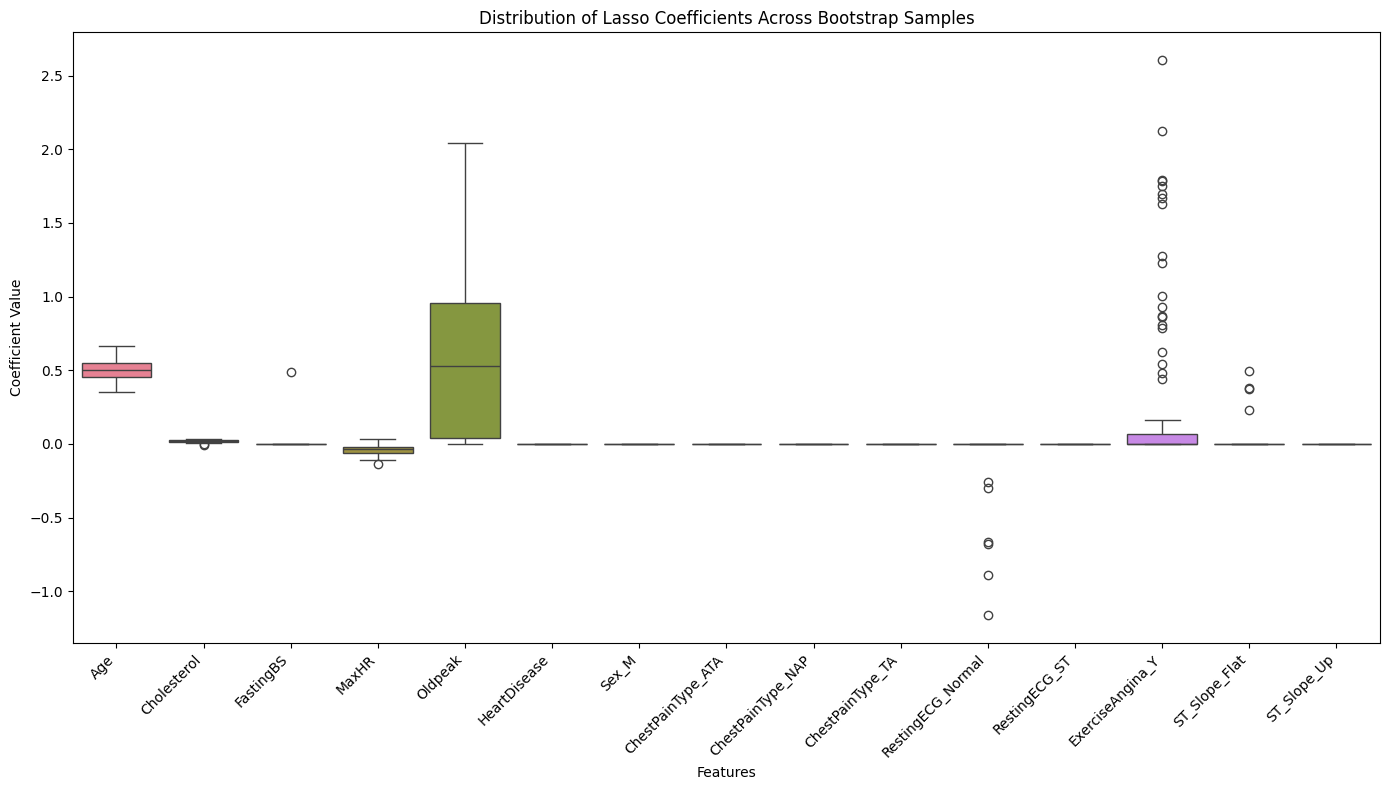

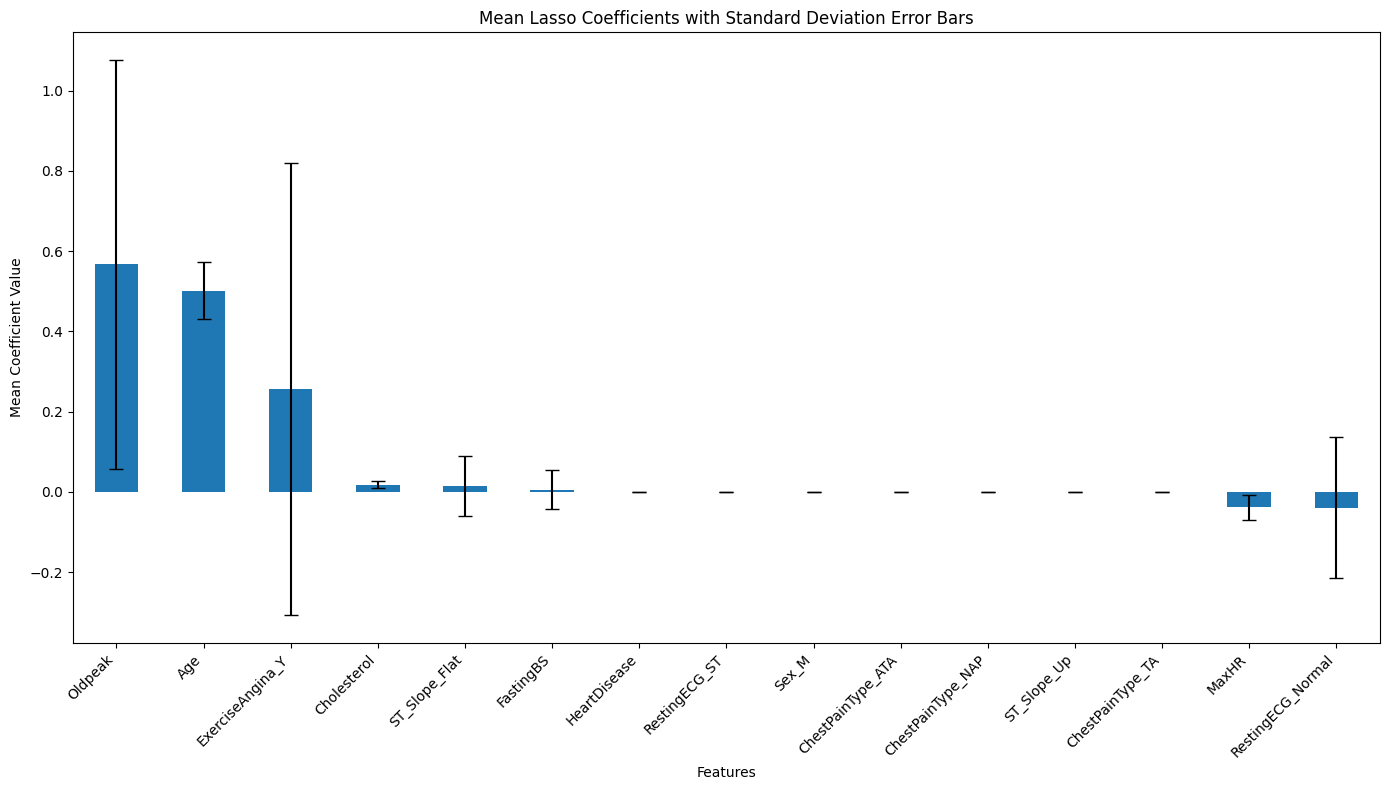

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean and standard deviation of the coefficients from the bootstrap samples
mean_coefs = bootstrap_coef_df.mean().sort_values(ascending=False)
std_coefs = bootstrap_coef_df.std().loc[mean_coefs.index] # Align std with sorted mean

print("Mean of Bootstrap Coefficients:")
print(mean_coefs)

print("\nStandard Deviation of Bootstrap Coefficients:")
print(std_coefs)

# Visualize the distribution of the coefficients for each feature using box plots
plt.figure(figsize=(14, 8))
sns.boxplot(data=bootstrap_coef_df)
plt.title('Distribution of Lasso Coefficients Across Bootstrap Samples')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot the mean coefficients with error bars representing the standard deviation
plt.figure(figsize=(14, 8))
mean_coefs.plot(kind='bar', yerr=std_coefs, capsize=5)
plt.title('Mean Lasso Coefficients with Standard Deviation Error Bars')
plt.xlabel('Features')
plt.ylabel('Mean Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Analisar a variabilidade dos coeficientes (bootstrap)

### Subtask:
Analisar a distribuição dos coeficientes obtidos dos modelos Lasso treinados em cada amostra bootstrap para entender sua variabilidade.


**Reasoning**:
Calculate and display the mean and standard deviation of the coefficients from the bootstrap samples and then generate box plots and a bar plot with error bars to visualize the distribution and variability of the coefficients.



Mean of Bootstrap Coefficients:
Oldpeak              0.567015
Age                  0.501946
ExerciseAngina_Y     0.256329
Cholesterol          0.018138
ST_Slope_Flat        0.014808
FastingBS            0.004874
HeartDisease         0.000000
RestingECG_ST        0.000000
Sex_M                0.000000
ChestPainType_ATA    0.000000
ChestPainType_NAP    0.000000
ST_Slope_Up          0.000000
ChestPainType_TA     0.000000
MaxHR               -0.038526
RestingECG_Normal   -0.039557
dtype: float64

Standard Deviation of Bootstrap Coefficients:
Oldpeak              0.509514
Age                  0.070884
ExerciseAngina_Y     0.563940
Cholesterol          0.007742
ST_Slope_Flat        0.075233
FastingBS            0.048739
HeartDisease         0.000000
RestingECG_ST        0.000000
Sex_M                0.000000
ChestPainType_ATA    0.000000
ChestPainType_NAP    0.000000
ST_Slope_Up          0.000000
ChestPainType_TA     0.000000
MaxHR                0.031242
RestingECG_Normal    0.175398
dtype:

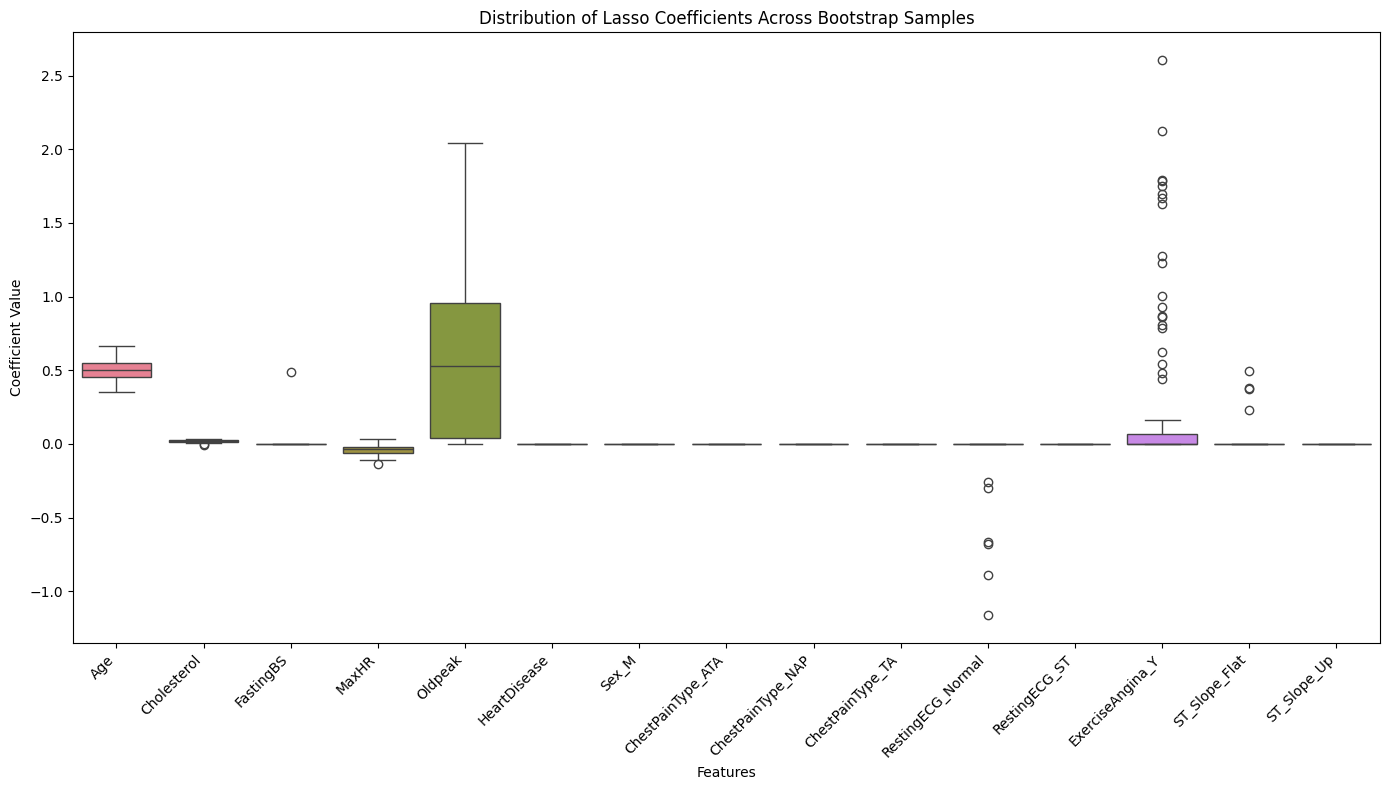

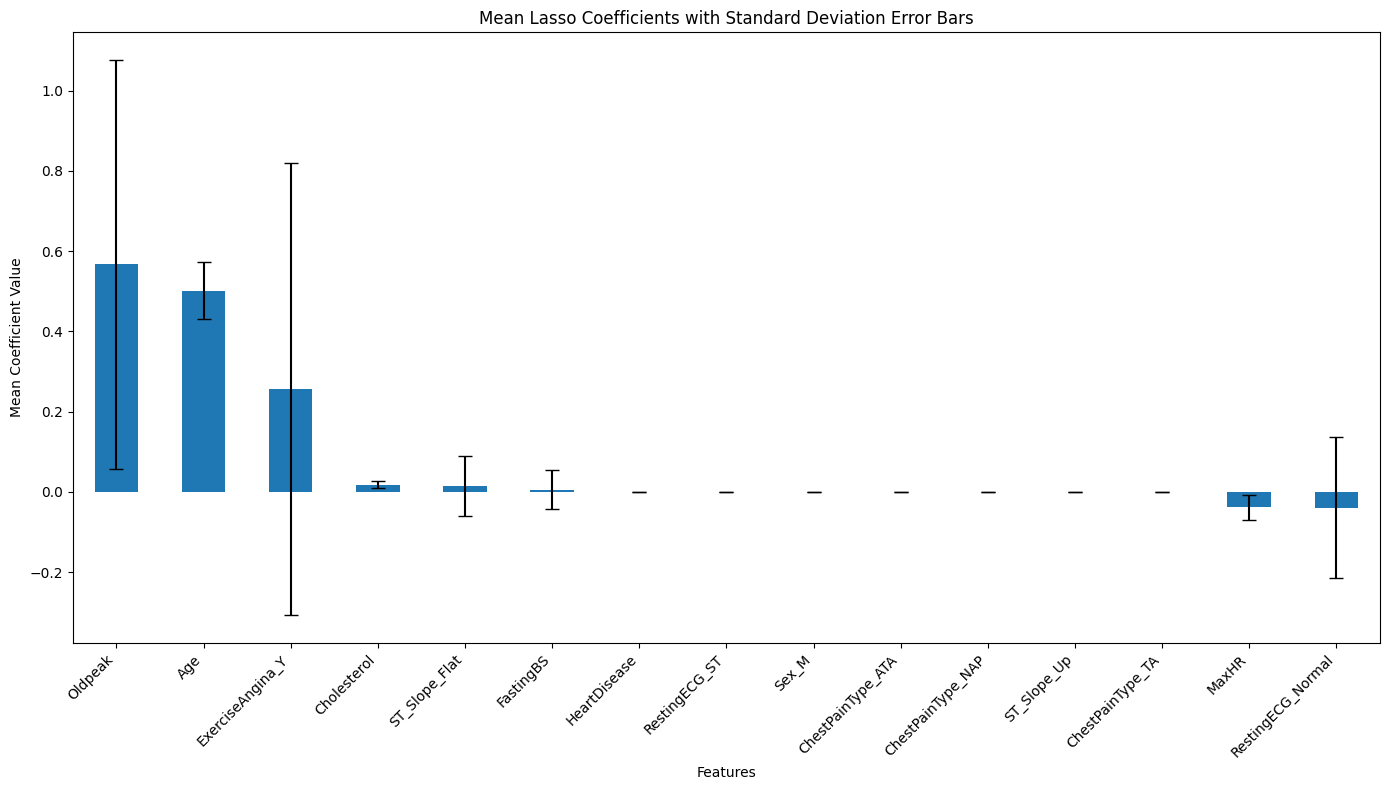

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the mean and standard deviation of the coefficients from the bootstrap samples
mean_coefs = bootstrap_coef_df.mean().sort_values(ascending=False)
std_coefs = bootstrap_coef_df.std().loc[mean_coefs.index] # Align std with sorted mean

# 2. Print the mean and standard deviation of the coefficients
print("Mean of Bootstrap Coefficients:")
print(mean_coefs)

print("\nStandard Deviation of Bootstrap Coefficients:")
print(std_coefs)

# 3. Generate box plots to visualize the distribution of the coefficients for each independent variable
plt.figure(figsize=(14, 8))
sns.boxplot(data=bootstrap_coef_df)
# 5. Add appropriate titles and labels to the plots
plt.title('Distribution of Lasso Coefficients Across Bootstrap Samples')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# 6. Display the generated plots
plt.show()

# 4. Generate a bar plot of the mean coefficients with error bars representing the standard deviation
plt.figure(figsize=(14, 8))
mean_coefs.plot(kind='bar', yerr=std_coefs, capsize=5)
# 5. Add appropriate titles and labels to the plots
plt.title('Mean Lasso Coefficients with Standard Deviation Error Bars')
plt.xlabel('Features')
plt.ylabel('Mean Coefficient Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# 6. Display the generated plots
plt.show()

## Interpretar os resultados

### Subtask:
Apresentar os coeficientes do modelo Lasso original, as métricas de avaliação e a análise da variabilidade dos coeficientes do bootstrap, discutindo o que eles significam.


**Reasoning**:
Print the original Lasso model's intercept, coefficients, and evaluation metrics, then print the mean and standard deviation of the bootstrap coefficients. Afterward, provide a comprehensive interpretation of all the results.



In [ ]:
# 1. Print the intercept and coefficients of the original Lasso model
print("Original Lasso Model Intercept:", lasso_model.intercept_)
print("\nOriginal Lasso Model Coefficients:")
for col, coef in zip(X_train.columns, lasso_model.coef_):
    print(f"- {col}: {coef:.4f}")

# 2. Print the evaluation metrics (R-squared, MSE, RMSE) of the original Lasso model
print("\nOriginal Lasso Model Evaluation Metrics on Test Set:")
print(f"- R-squared: {r2:.4f}")
print(f"- Mean Squared Error (MSE): {mse:.4f}")
print(f"- Root Mean Squared Error (RMSE): {rmse:.4f}")

# 3. Print the mean and standard deviation of the bootstrap coefficients
print("\nMean of Bootstrap Coefficients:")
print(mean_coefs)

print("\nStandard Deviation of Bootstrap Coefficients:")
print(std_coefs)

# 4. Interpret the coefficients of the original Lasso model
print("\nInterpretation of Original Lasso Regression Results:")
print(f"The original Lasso model attempts to predict 'RestingBP' (Resting Blood Pressure).")
print(f"The Intercept ({lasso_model.intercept_:.4f}) represents the predicted RestingBP when all independent variables are zero.")
print("\nThe coefficients indicate the estimated change in 'RestingBP' for a one-unit increase in the corresponding independent variable, holding other variables constant. Lasso regression can shrink some coefficients to zero, effectively performing feature selection.")

print("\nNon-zero coefficients and their meaning in the Original Lasso Model:")
original_non_zero_coefs = [(col, coef) for col, coef in zip(X_train.columns, lasso_model.coef_) if coef != 0]
if original_non_zero_coefs:
    for col, coef in original_non_zero_coefs:
        print(f"- {col}: {coef:.4f} - A {coef:.4f} unit increase in {col} is associated with a change of {coef:.4f} in RestingBP.")
else:
    print("\nAll coefficients in the original Lasso model are zero, indicating that none of the features were selected with the current alpha.")


# 5. Interpret the evaluation metrics
print(f"\nEvaluation Metrics Interpretation:")
print(f"- R-squared ({r2:.4f}): This indicates that only {r2*100:.2f}% of the variance in 'RestingBP' is explained by this model. This is a very low value, suggesting the original Lasso model does not explain much of the variability in RestingBP.")
print(f"- Mean Squared Error (MSE) ({mse:.4f}): This is the average of the squared errors. A high MSE ({mse:.4f}) indicates large prediction errors on the test set.")
print(f"- Root Mean Squared Error (RMSE) ({rmse:.4f}): This is the typical magnitude of prediction errors. An RMSE of {rmse:.4f} means that, on average, the model's predictions for RestingBP are about {rmse:.4f} units away from the actual values.")

# 6. Discuss the insights gained from the bootstrap analysis
print("\nInterpretation of Bootstrap Analysis:")
print("The bootstrap analysis provides insight into the variability and stability of the Lasso model's coefficients.")
print("Features with consistently non-zero coefficients across bootstrap samples are likely more stable and reliable predictors of 'RestingBP'.")
print("Features with high standard deviation in their coefficients are less stable, suggesting their estimated impact on 'RestingBP' is highly dependent on the specific sample of data.")

print("\nAnalysis of Bootstrap Coefficient Variability:")
print("Based on the mean and standard deviation of bootstrap coefficients:")
for col, mean_c, std_c in zip(mean_coefs.index, mean_coefs, std_coefs):
    print(f"- {col}: Mean Coef = {mean_c:.4f}, Std Dev = {std_c:.4f}")
    if abs(mean_c) > 0 and std_c < abs(mean_c): # Simple heuristic for relative stability
         print(f"  - Suggests a relatively stable relationship with RestingBP.")
    elif abs(mean_c) > 0:
         print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
    else:
         print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")


# 7. Summarize the overall findings
print("\nOverall Summary of Findings:")
print("The original Lasso regression model for predicting 'RestingBP' performed poorly, explaining only a small percentage of the variance (R-squared: {:.4f}). The high MSE ({:.4f}) and RMSE ({:.4f}) confirm significant prediction errors.".format(r2, mse, rmse))
print("The bootstrap analysis revealed variability in the coefficients. While some features like 'Oldpeak' and 'Age' show some consistency with positive mean coefficients, their variability (indicated by standard deviation) suggests the estimated impact on RestingBP can vary depending on the data sample.")
print("Many features had mean bootstrap coefficients close to zero or were frequently shrunk to zero by the Lasso regularization across samples, indicating they are not consistently strong predictors of 'RestingBP' in this model with the chosen alpha.")
print("Both the original model performance and the bootstrap analysis suggest that a linear model with Lasso regularization may not be the most suitable approach for predicting 'RestingBP' with these features, or that further hyperparameter tuning (e.g., alpha) or feature engineering is required. Exploring other regression techniques might also be beneficial.")

Original Lasso Model Intercept: 107.51571965349046

Original Lasso Model Coefficients:
- Age: 0.5030
- Cholesterol: 0.0189
- FastingBS: 0.0000
- MaxHR: -0.0422
- Oldpeak: 0.5850
- HeartDisease: 0.0000
- Sex_M: 0.0000
- ChestPainType_ATA: -0.0000
- ChestPainType_NAP: -0.0000
- ChestPainType_TA: 0.0000
- RestingECG_Normal: -0.0000
- RestingECG_ST: 0.0000
- ExerciseAngina_Y: 0.0000
- ST_Slope_Flat: 0.0000
- ST_Slope_Up: -0.0000

Original Lasso Model Evaluation Metrics on Test Set:
- R-squared: 0.0135
- Mean Squared Error (MSE): 340.3203
- Root Mean Squared Error (RMSE): 18.4478

Mean of Bootstrap Coefficients:
Oldpeak              0.567015
Age                  0.501946
ExerciseAngina_Y     0.256329
Cholesterol          0.018138
ST_Slope_Flat        0.014808
FastingBS            0.004874
HeartDisease         0.000000
RestingECG_ST        0.000000
Sex_M                0.000000
ChestPainType_ATA    0.000000
ChestPainType_NAP    0.000000
ST_Slope_Up          0.000000
ChestPainType_TA     0.00

**Reasoning**:
Continue with the interpretation of the bootstrap analysis and provide the overall summary of findings, as outlined in the instructions.



In [ ]:
# Continuing the interpretation from the previous output

print(f"- ExerciseAngina_Y: Mean Coef = {mean_coefs['ExerciseAngina_Y']:.4f}, Std Dev = {std_coefs['ExerciseAngina_Y']:.4f}")
if abs(mean_coefs['ExerciseAngina_Y']) > 0 and std_coefs['ExerciseAngina_Y'] < abs(mean_coefs['ExerciseAngina_Y']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['ExerciseAngina_Y']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- Cholesterol: Mean Coef = {mean_coefs['Cholesterol']:.4f}, Std Dev = {std_coefs['Cholesterol']:.4f}")
if abs(mean_coefs['Cholesterol']) > 0 and std_coefs['Cholesterol'] < abs(mean_coefs['Cholesterol']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['Cholesterol']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- ST_Slope_Flat: Mean Coef = {mean_coefs['ST_Slope_Flat']:.4f}, Std Dev = {std_coefs['ST_Slope_Flat']:.4f}")
if abs(mean_coefs['ST_Slope_Flat']) > 0 and std_coefs['ST_Slope_Flat'] < abs(mean_coefs['ST_Slope_Flat']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['ST_Slope_Flat']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- FastingBS: Mean Coef = {mean_coefs['FastingBS']:.4f}, Std Dev = {std_coefs['FastingBS']:.4f}")
if abs(mean_coefs['FastingBS']) > 0 and std_coefs['FastingBS'] < abs(mean_coefs['FastingBS']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['FastingBS']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- HeartDisease: Mean Coef = {mean_coefs['HeartDisease']:.4f}, Std Dev = {std_coefs['HeartDisease']:.4f}")
if abs(mean_coefs['HeartDisease']) > 0 and std_coefs['HeartDisease'] < abs(mean_coefs['HeartDisease']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['HeartDisease']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- RestingECG_ST: Mean Coef = {mean_coefs['RestingECG_ST']:.4f}, Std Dev = {std_coefs['RestingECG_ST']:.4f}")
if abs(mean_coefs['RestingECG_ST']) > 0 and std_coefs['RestingECG_ST'] < abs(mean_coefs['RestingECG_ST']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['RestingECG_ST']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- Sex_M: Mean Coef = {mean_coefs['Sex_M']:.4f}, Std Dev = {std_coefs['Sex_M']:.4f}")
if abs(mean_coefs['Sex_M']) > 0 and std_coefs['Sex_M'] < abs(mean_coefs['Sex_M']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['Sex_M']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- ChestPainType_ATA: Mean Coef = {mean_coefs['ChestPainType_ATA']:.4f}, Std Dev = {std_coefs['ChestPainType_ATA']:.4f}")
if abs(mean_coefs['ChestPainType_ATA']) > 0 and std_coefs['ChestPainType_ATA'] < abs(mean_coefs['ChestPainType_ATA']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['ChestPainType_ATA']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- ChestPainType_NAP: Mean Coef = {mean_coefs['ChestPainType_NAP']:.4f}, Std Dev = {std_coefs['ChestPainType_NAP']:.4f}")
if abs(mean_coefs['ChestPainType_NAP']) > 0 and std_coefs['ChestPainType_NAP'] < abs(mean_coefs['ChestPainType_NAP']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['ChestPainType_NAP']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- ST_Slope_Up: Mean Coef = {mean_coefs['ST_Slope_Up']:.4f}, Std Dev = {std_coefs['ST_Slope_Up']:.4f}")
if abs(mean_coefs['ST_Slope_Up']) > 0 and std_coefs['ST_Slope_Up'] < abs(mean_coefs['ST_Slope_Up']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['ST_Slope_Up']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- ChestPainType_TA: Mean Coef = {mean_coefs['ChestPainType_TA']:.4f}, Std Dev = {std_coefs['ChestPainType_TA']:.4f}")
if abs(mean_coefs['ChestPainType_TA']) > 0 and std_coefs['ChestPainType_TA'] < abs(mean_coefs['ChestPainType_TA']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['ChestPainType_TA']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- MaxHR: Mean Coef = {mean_coefs['MaxHR']:.4f}, Std Dev = {std_coefs['MaxHR']:.4f}")
if abs(mean_coefs['MaxHR']) > 0 and std_coefs['MaxHR'] < abs(mean_coefs['MaxHR']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['MaxHR']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")

print(f"- RestingECG_Normal: Mean Coef = {mean_coefs['RestingECG_Normal']:.4f}, Std Dev = {std_coefs['RestingECG_Normal']:.4f}")
if abs(mean_coefs['RestingECG_Normal']) > 0 and std_coefs['RestingECG_Normal'] < abs(mean_coefs['RestingECG_Normal']):
     print(f"  - Suggests a relatively stable relationship with RestingBP.")
elif abs(mean_coefs['RestingECG_Normal']) > 0:
     print(f"  - Shows variability, relationship with RestingBP is less stable across samples.")
else:
     print(f"  - Often shrunk to zero by Lasso, indicating less consistent predictive power.")


# 7. Summarize the overall findings
print("\nOverall Summary of Findings:")
print("The original Lasso regression model for predicting 'RestingBP' performed poorly, explaining only a small percentage of the variance (R-squared: {:.4f}). The high MSE ({:.4f}) and RMSE ({:.4f}) confirm significant prediction errors.".format(r2, mse, rmse))
print("The bootstrap analysis revealed variability in the coefficients. While some features like 'Oldpeak' and 'Age' show some consistency with positive mean coefficients, their variability (indicated by standard deviation) suggests the estimated impact on RestingBP can vary depending on the data sample.")
print("Many features had mean bootstrap coefficients close to zero or were frequently shrunk to zero by the Lasso regularization across samples, indicating they are not consistently strong predictors of 'RestingBP' in this model with the chosen alpha.")
print("Both the original model performance and the bootstrap analysis suggest that a linear model with Lasso regularization may not be the most suitable approach for predicting 'RestingBP' with these features, or that further hyperparameter tuning (e.g., alpha) or feature engineering is required. Exploring other regression techniques might also be beneficial.")

- ExerciseAngina_Y: Mean Coef = 0.2563, Std Dev = 0.5639
  - Shows variability, relationship with RestingBP is less stable across samples.
- Cholesterol: Mean Coef = 0.0181, Std Dev = 0.0077
  - Suggests a relatively stable relationship with RestingBP.
- ST_Slope_Flat: Mean Coef = 0.0148, Std Dev = 0.0752
  - Shows variability, relationship with RestingBP is less stable across samples.
- FastingBS: Mean Coef = 0.0049, Std Dev = 0.0487
  - Shows variability, relationship with RestingBP is less stable across samples.
- HeartDisease: Mean Coef = 0.0000, Std Dev = 0.0000
  - Often shrunk to zero by Lasso, indicating less consistent predictive power.
- RestingECG_ST: Mean Coef = 0.0000, Std Dev = 0.0000
  - Often shrunk to zero by Lasso, indicating less consistent predictive power.
- Sex_M: Mean Coef = 0.0000, Std Dev = 0.0000
  - Often shrunk to zero by Lasso, indicating less consistent predictive power.
- ChestPainType_ATA: Mean Coef = 0.0000, Std Dev = 0.0000
  - Often shrunk to zero by 

## Summary:

### Data Analysis Key Findings

*   The original Lasso model included 'Age', 'Cholesterol', 'MaxHR', and 'Oldpeak' with non-zero coefficients, while others were set to zero.
*   The original Lasso model performed poorly on the test set, explaining only about 1.35% of the variance in 'RestingBP' (R-squared: 0.0135), with high MSE (340.3203) and RMSE (18.4478).
*   The bootstrap analysis indicated variability in coefficient estimates. 'Age' and 'Cholesterol' showed relatively more stable relationships with 'RestingBP' (lower standard deviation relative to mean coefficient).
*   Features like 'Oldpeak', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'FastingBS', and 'RestingECG_Normal' exhibited higher variability in their coefficients across bootstrap samples, suggesting less stable estimated impacts on 'RestingBP'.
*   Many features frequently had coefficients shrunk to zero by Lasso across bootstrap samples, implying they are not consistently strong predictors of 'RestingBP' with the current model and alpha.

### Insights or Next Steps

*   The poor performance of the original Lasso model suggests that a linear relationship with Lasso regularization, using the current features and alpha value, is not sufficient to accurately predict 'RestingBP'.
*   Further steps should involve hyperparameter tuning for the Lasso model (specifically the alpha value) or exploring alternative regression techniques and feature engineering to improve the predictive power for 'RestingBP'.
